In [ ]:
# using Pkg
# Pkg.activate("..")

using ITensors
using ITensorMPS
using PolyChaos
using LinearAlgebra
using Plots
using Observers
using Kronecker
using SparseArrays

using CorrelationProject

"""
This notebook and associated code allows for an arbitary tight bidnding fermionic 
system coupled to two fermionic baths (can do one by setting N=0 for one of the baths),
modelled using the thermofield chain mapping. The function multitime_correlators_using_NMQMpE_using_MPS
implements the algorithm defined in arXiv:2510.26651. This is a simplified version of the original code,
so only allows for a separated ordering for the system and system ancilla modes, and only allows for spinless
fermionic systems. It's far from being production code and I apologise in advance for the lack of documentation and the messy code!
"""


Id_check(Λi) = 4.440892098500626e-16

    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################
map_step = 5
After sweep 1: maxlinkdim=10 maxerr=7.22E-16 current_time=0.0 - 0.1im time=0.236
sim_t = 0.1
After sweep 1: maxlinkdim=10 maxerr=3.88E-16 current_time=0.0 - 0.1im time=0.326
sim_t = 0.2
After sweep 1: maxlinkdim=10 maxerr=7.85E-16 current_time=0.0 - 0.1im time=0.998
sim_t = 0.30000000000000004
After sweep 1: maxlinkdim=10 maxerr=4.46E-16 current_time=0.0 - 0.1im time=1.164
sim_t = 0.4
After sweep 1: maxlinkdim=10 maxerr=8.46E-16 current_time=0.0 - 0.1im time=1.119
sim_t = 0.5
After sweep 1: maxlinkdim=10 maxerr=6.98E-16 current_time=0.0 + 0.1im time=0.11
After sweep 1: maxlinkdim=10 maxerr=6.47E-16 current_time=0.0 - 0.1im time=0.114
Time taken for map extraction
  0.012050 seconds (351.84 k allocations: 39.600 MiB)
Aft

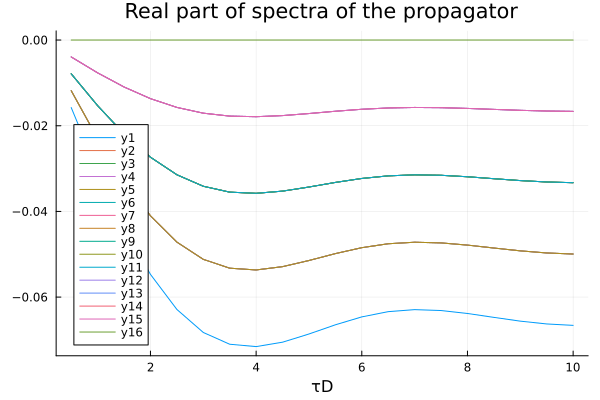

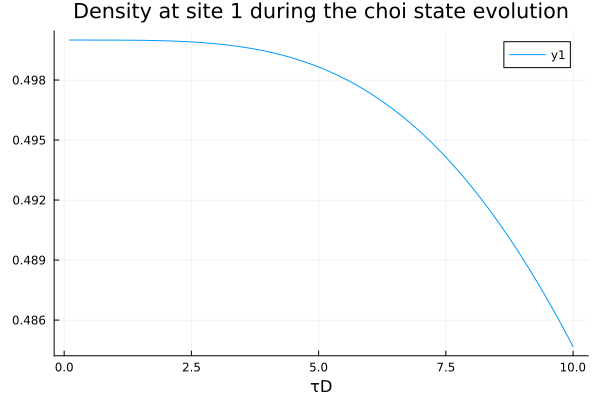

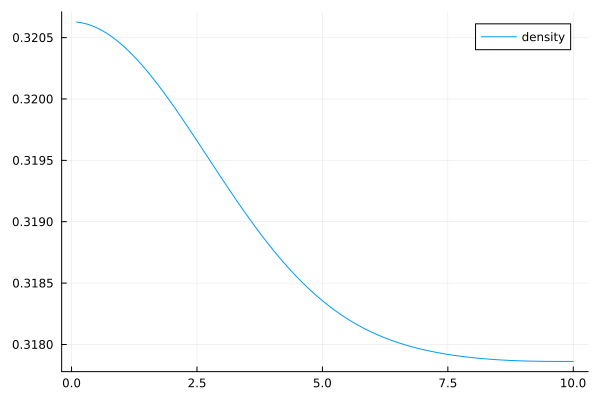

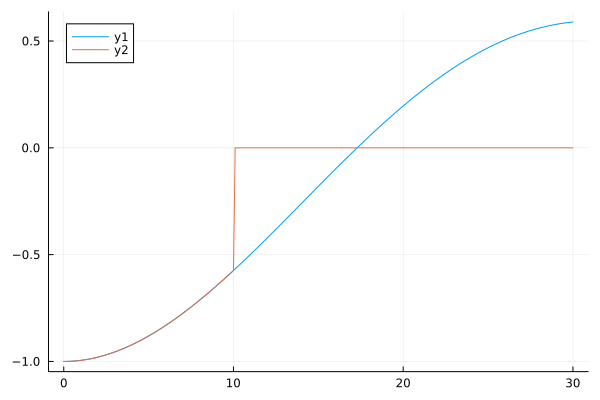

In [ ]:
function multitime_correlators_using_NMQMpE_using_MPS(ψ0,H_MPO,τmL1,τmL2,τmL3,TDVP_params,end_time,site,layout;kwargs...)

    """
    multitime_correlators_using_NMQMpE_using_MPS(
        ψ0,
        H_MPO,
        τmL1,
        τmL2,
        τmL3,
        TDVP_params,
        end_time,
        site;
        kwargs...
    )

    Calculate impurity/system Green's functions using an NMQMpE-accelerated MPS
    protocol.

    The calculation proceeds in three stages:

    1. **Map and steady-state construction.**
    The initial Choi/vectorised state `ψ0` is evolved with the full system-bath
    Hamiltonian `H_MPO` up to time `τmL1`. During this evolution, dynamical maps
    `Λ(t)` and corresponding generators/propagators `L(t)` are extracted. The
    steady state is obtained from the zero eigenvector of `L(τmL1)`, and the
    NMQMpE fast state `ρf` is estimated by applying the pseudoinverse of the
    converged dynamical map.

    2. **Preparation of the stationary state.**
    The fast state `ρf` is converted back into a purified/vectorised MPS and
    evolved with the full system-bath Hamiltonian for a further time `τmL2`.
    By construction, the reduced system state should approach the steady state
    after this evolution.

    3. **Correlation-function propagation.**
    Once the state has reached stationarity, the MPS is perturbed with the
    appropriate fermionic creation/annihilation operators at the selected system
    `site`. The perturbed MPSs are evolved explicitly with TDVP up to time
    `τmL3`. After this memory time, the reduced perturbed density matrices are
    propagated using the converged reduced generator rather than the full
    system-bath dynamics.

    # Arguments

    - `ψ0`: Initial MPS, typically representing the vectorised/Choi initial state
    used to compute the dynamical map.

    - `H_MPO`: MPO representation of the full system-bath Hamiltonian.

    - `τmL1::Real`: Evolution time used to compute the dynamical maps, generators,
    and steady state.

    - `τmL2::Real`: Evolution time used to evolve the NMQMpE fast state towards
    stationarity under the full system-bath Hamiltonian.

    - `τmL3::Real`: Explicit TDVP evolution time for the perturbed states before
    switching to reduced-system propagation with the converged generator.

    - `TDVP_params`: Parameter object controlling the TDVP evolution. Expected to
    contain fields such as `δt`, `tdvp_cutoff`, `minbonddim`, `maxbonddim`, and
    `total_simulation_time`.

    - `end_time::Real`: Final time up to which the Green's functions are computed.
    Must satisfy `end_time >= τmL2 + τmL3`.

    - `site::Int`: Index of the system site at which the fermionic creation and
    annihilation operators are applied.

    - `layout`: Choice of layout for the MPS representation..

    # Keyword arguments

    - `enrich_bool = false`: Whether to use MPS enrichment during propagation.

    - `ordering_choice = "separated"`: Choice of system-ancilla ordering. The
    function assumes `"separated"` ordering when converting the reduced fast state
    back into an MPS. `"interleaved"` ordering is detected but not implemented.

    - `plotting_bool = false`: If `true`, display diagnostic plots of propagator
    spectra and selected site occupations.

    - `memory_time_ind = false`: If set to an integer index, use the corresponding
    stored map/generator/steady-state object instead of the final one.

    # Returns

    A `Dict` containing the calculated Green's functions, time grid, intermediate
    maps, evolved MPSs, and diagnostic quantities. Important entries include:

    - `"Grn_t"`: Time-ordered Green's function.
    - `"Grn_lesser"`: Lesser Green's function.
    - `"Grn_greater"`: Greater Green's function.
    - `"total_times"`: Time grid from `0` to `end_time`.
    - `"L_vec"`: Vector of reduced generators/propagators extracted during map
    calculation.
    - `"Λ_vec"`: Vector of dynamical maps extracted during map calculation.
    - `"SS_prep_obs"`: Observer data from the fast-state preparation evolution.
    - `"map_calc_obs"`: Observer data from the dynamical-map calculation.
    - `"ρf_MPS"`: MPS representation of the NMQMpE fast state (commented out).
    - `"ρf_MPS_evolved"`: Fast-state MPS after evolution towards stationarity (commented out).
    - `"ρ_tilde_lesser"`: Final reduced lesser perturbed density matrix.
    - `"ρ_tilde_greater"`: Final reduced greater perturbed density matrix.
    - `"τmLs"`: Vector `[τmL1, τmL2, τmL3]`.
    - `"ϕ_R_lesser"`, `"ϕ_L_greater"`, `"ϕ"`: Final MPSs used in the explicit
    perturbed-state propagation (commented out).
    - `"Grn_t_test"`: Alternative diagnostic calculation of the time-ordered
    Green's function.
    - `"ρ_tilde_greater_vec"`: Stored reduced greater perturbed density matrices
    during explicit TDVP evolution.
    - `"ρ_tilde_lesser_vec"`: Stored reduced lesser perturbed density matrices
    during explicit TDVP evolution.

    # Assumptions

    This function assumes that several helper functions are
    available in scope, including `calculateDynamicalMap`, `Id_check`,
    `propagate_MPS`, `calculate_spectra_and_steady_state`, `map_check`,
    `unvectorise_ρ`, `vectorise_ρ`, `vectorise_mat`, `rdm_to_MPS`,
    `create_fermi_cre_op`, `create_fermi_ann_op`, `matrix_operators`,
    `spin_operators`, and `lmult`.

    The implementation is currently specialised to fermionic Green's functions,
    since it explicitly applies `"Cdag"` and `"C"` operators and uses fermionic
    parity corrections.

    # Notes

    The function mutates `TDVP_params.total_simulation_time` internally during the
    different propagation stages. If the original value is needed later, store it
    before calling this function.

    The function also assumes that the system and ancilla are in separated ordering
    when constructing the purified MPS representation of `ρf`; interleaved ordering
    is explicitly reported as unsupported.
    """

    enrich_bool = get(kwargs,:enrich_bool,false)
    #take_symmetry_subset = get(kwargs,:take_symmetry_subset,false)
    ordering_choice = get(kwargs,:ordering_choice,"separated")
    plotting_bool = get(kwargs,:plotting_bool,false)
    memory_time_ind = get(kwargs,:memory_time_ind,false)
    @assert(end_time >= τmL2+τmL3)

    #times vectors for the first two time evolutions, used for plotting
    times1 = range(TDVP_params.δt,stop=τmL1,step = TDVP_params.δt)
    times2 = range(TDVP_params.δt,stop=τmL2,step = TDVP_params.δt) 

    #Checking identity map
    Λi = calculateDynamicalMap(ψ0,layout,ordering_choice)
    @show(Id_check(Λi))

    #Step 1
    println("
    #######################################################################
    Time evolution to calculate maps, propagators and steady state.
    #######################################################################")
    

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time= τmL1
    ψ,map_calc_obs,L_vec,Λ_vec,map_times =  propagate_MPS(ψ0,H_MPO,obs,TDVP_params,layout;compute_maps_bool=true,enrich_bool=enrich_bool,kwargs...)

    spectra_vec,SS_vec = calculate_spectra_and_steady_state(L_vec)
    if plotting_bool
        #density at the site of interest during the choi state evolution
        den_vec = [corr[site,site] for corr in obs.corr]
        
        display(Plots.plot(map_times,real.(spectra_vec),title="Real part of spectra of the propagator",xlabel="τD"))
        display(Plots.plot(times2,real.(den_vec),title="Density at site $site during the choi state evolution",xlabel="τD"))
    end

    #gives an option to choose the specific point where the fast state is calculated
    if memory_time_ind == false
        Lτm,Λτm,steady_state = L_vec[end],Λ_vec[end],SS_vec[end]
    else
        Lτm,Λτm,steady_state = Lτm,[Int(memory_time_ind)],Λ_vec[Int(memory_time_ind)],SS_vec[Int(memory_time_ind)]
    end


    @show(map_check(ψ,ψ0,Λτm,layout))

    # if take_symmetry_subset
    #     ρf= unvectorise_ρ(expand_Λ(pinv(Λτm),P.Ns)*NESS,true)
    # else
    ρf= unvectorise_ρ(pinv(Λτm)*steady_state,true)

    #if ρf is unphysical, this finds one that is
    if sum(real.(eigen(ρf).values) .<0) > 0
        ρf_bool = false
        for i =reverse(1:length(L_vec))
            spec = eigen(L_vec[i]).values
            vecs = eigen(L_vec[i]).vectors
            steady_state_i = vecs[:,argmin(abs.(spec))]
            ρf_test = unvectorise_ρ(pinv(Λ_vec[i])*steady_state_i,true)
            if sum(real.(eigen(ρf).values) .<0) == 0
                ρf = ρf_test   
                ρf_bool = true
            end
        end
        if ρf_bool == false
            ρf = unvectorise_ρ(steady_state,true)
        end
    end  


    if ordering_choice == "interleaved"
        println("
        For the purified MPS to give the fast state after 
        tracing out, the ancillas must be contiguous. So, if
        an interleaved system-ancilla setup was used to calculate the 
        map, then this must be switched at this point. This code assumes a separated ordering
        is used at all times to avoid this complication, so using an interleaved ordering
        is not currently implemented")
    end

    #creating an MPS that defines the purified ρf
    ρf_MPS = rdm_to_MPS(ρf,siteinds(ψ),layout)

    #testing it gives the fast state after tracing out
    ρf_test = vectorise_ρ(ρf_MPS,layout)

    
    @show(norm(ρf_test-vectorise_mat(ρf)))

    println("
    #######################################################################
    Time evolution towards stationarity, starting with ρf
    #######################################################################")
    #Step 2

    #create observer for tdvp
    obs = Observer("times" => current_time,"corr" => measure_correlation_matrix)

    TDVP_params.total_simulation_time = τmL2
    ρf_MPS_evolved,SS_prep_obs=  propagate_MPS(ρf_MPS,H_MPO,obs,TDVP_params,layout;compute_maps_bool = false,enrich_bool=enrich_bool,kwargs...)
    
    #some plotting showing the thermalisation
    corrs = SS_prep_obs.corr
    den_vec = [corr[site,site] for corr in corrs]
    if plotting_bool
        display(Plots.plot(times2,real.(den_vec),label="density"))
    end

        
    ρf_evolved_mat = vectorise_ρ(ρf_MPS_evolved,layout)
    #Test to show if ρf gives the steady state after the evolution
    # if take_symmetry_subset
    #     @show(norm(ρf_evolved_mat-expand_Λ(Λτm,P.Ns)*ρf_test))
    # else
    @show(norm(ρf_evolved_mat-Λτm*ρf_test))
    @show(norm(steady_state-ρf_evolved_mat))


    println("
    #######################################################################
    Once stationary the state is perturbed with the appropriate 
    creation/annihilation operators for the greens function calulations.
    #######################################################################")
    ##Creating ϕ_L_greater, ϕ_R_greater, ϕ_L_lesser and ϕ_R_lesser
    ##ϕ_R_greater and ϕ_L_lesser are calculated from ϕ=U(t)*ρf_evolved
    ϕ = deepcopy(ρf_MPS_evolved)

    s = siteinds(ϕ)
    ϕ_L_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
    ϕ_R_lesser = apply(create_fermi_ann_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

    Nsteps = Int(end_time/TDVP_params.δt)
    Grn_t = zeros(ComplexF64, Nsteps+1)
    Grn_lesser,Grn_greater = similar(Grn_t),similar(Grn_t)
    Grn_t[1] = -1.0*im ##t=0 value
    Grn_t_test = deepcopy(Grn_t)

    println("
    #######################################################################
    The three MPSs required for the greens function are propagated for a time
    τmL, after which their evolution can be described by propagation
    with the fixed propagator.
    #######################################################################")
    # Configure updater parameters
    updater_kwargs = Dict(:ishermitian => true, :issymmetric => true, :eager => true)
    sim_t = 0
    no_of_tdvp_steps = Int(τmL3/TDVP_params.δt)


    cdag_mat,c_mat = matrix_operators(length(layout.system))
    ρ_tilde_lesser_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_greater_vec = Vector{Any}(undef,Nsteps+1)
    ρ_tilde_lesser_vec[1] = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...)
    ρ_tilde_greater_vec[1] = vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)

    
    for i =1:(no_of_tdvp_steps)
        ϕ_L_greater= tdvp(H_MPO,-im * TDVP_params.δt,ϕ_L_greater; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs, reverse_step = true)
    
        ϕ_R_lesser = tdvp(H_MPO,-im * TDVP_params.δt,ϕ_R_lesser; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=false,updater_kwargs,reverse_step = true)

        ϕ = tdvp(H_MPO,-im * TDVP_params.δt,ϕ; time_step = -im * TDVP_params.δt, cutoff = TDVP_params.tdvp_cutoff,
        mindim=TDVP_params.minbonddim,maxdim=TDVP_params.maxbonddim,outputlevel=1, normalize=true,updater_kwargs,reverse_step = true)
        
        ##Calculating ϕ_R_greater and ϕ_L_lesser
        ϕ_R_greater = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"Cdag",layout.system[site]),s),ϕ)
        ϕ_L_lesser = apply(create_fermi_cre_op(layout.system[site],[layout.system;layout.ancilla],op(s,"C",layout.system[site]),s),ϕ)

        Grn_lesser[i+1] = im*inner(ϕ_R_lesser,ϕ_L_lesser)
        Grn_greater[i+1] = -im*inner(ϕ_R_greater,ϕ_L_greater)
        Grn_t[i+1] = Grn_greater[i+1]-Grn_lesser[i+1]

        ρ_tilde_lesser = vectorise_ρ(ϕ,ϕ_R_lesser,layout;rdm_block_sparse_bool = false,kwargs...) 
        ρ_tilde_greater= vectorise_ρ(ϕ_L_greater,ϕ,layout;rdm_block_sparse_bool = false,kwargs...)
        G_greater = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        G_lesser = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t_test[i+1] = G_greater-G_lesser

        ρ_tilde_lesser_vec[i+1] = ρ_tilde_lesser
        ρ_tilde_greater_vec[i+1] = ρ_tilde_greater
        sim_t += TDVP_params.δt
        @show(sim_t)
    end

    ρ_tilde_lesser = ρ_tilde_lesser_vec[no_of_tdvp_steps+1]
    ρ_tilde_greater = ρ_tilde_greater_vec[no_of_tdvp_steps+1]

    println("
    #######################################################################
    After τmL, ρ_tilde_lesser and ρ_tilde_greater are calculated and are 
    propagated using the converged propagator.
    #######################################################################")
    
    #Applies parity correction
    Sz = spin_operators(length(layout.system))[1]
    parity_op = Matrix(Sz[1])
    for i=2:length(layout.system)
        parity_op *= Matrix(Sz[i])
    end
    parity_op_vec = lmult(parity_op)
    Lbar_τm = parity_op_vec*Lτm*parity_op_vec

    remaining_steps = Int((end_time-τmL3)/TDVP_params.δt)
    for i = 1:remaining_steps
        ρ_tilde_lesser = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_lesser
        ρ_tilde_greater = exp(Lbar_τm*TDVP_params.δt)*ρ_tilde_greater

        Grn_greater[no_of_tdvp_steps+i+1] = -im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_greater,false))
        Grn_lesser[no_of_tdvp_steps+i+1] = im*tr(c_mat[site]*unvectorise_ρ(ρ_tilde_lesser,false))
        Grn_t[no_of_tdvp_steps+i+1] = Grn_greater[no_of_tdvp_steps+i+1]-Grn_lesser[no_of_tdvp_steps+i+1]
    end
    
    total_times = range(0,stop=end_time,step=TDVP_params.δt)
    output_dict = Dict()
    output_dict["Grn_t"] = Grn_t
    output_dict["Grn_lesser"] = Grn_lesser
    output_dict["Grn_greater"] = Grn_greater
    output_dict["total_times"] = total_times
    output_dict["L_vec"] = L_vec
    output_dict["Λ_vec"] = Λ_vec
    output_dict["SS_prep_obs"] = SS_prep_obs
    output_dict["map_calc_obs"] = map_calc_obs
    #output_dict["ρf_MPS"] = ρf_MPS
    #output_dict["ρf_MPS_evolved"] = ρf_MPS_evolved
    output_dict["ρ_tilde_lesser"] = ρ_tilde_lesser
    output_dict["ρ_tilde_greater"] = ρ_tilde_greater
    output_dict["τmLs"] = [τmL1,τmL2,τmL3]
    #output_dict["ϕ_R_lesser"] = ϕ_R_lesser
    #output_dict["ϕ_L_greater"] = ϕ_L_greater
    #output_dict["ϕ"] = ϕ
    output_dict["Grn_t_test"] = Grn_t_test
    output_dict["ρ_tilde_greater_vec"] = ρ_tilde_greater_vec
    output_dict["ρ_tilde_lesser_vec"] = ρ_tilde_lesser_vec
    return output_dict
end


"""
Define parameters
"""

left_bath = BathParameters(Γ = 0.05,β = 10.0,μ = 0.1,D = 1.0,N =0)

right_bath = BathParameters(Γ = 0.05,β = 10.0,μ = -0.1,D = 1.0,N = 10)

#The size of the system is determined by the length of the ϵ vector, which is the on-site energies of the system.
#The occupations vector defines the initial occupations of the system sites, and can be "Emp" or "Occ" for empty or occupied respectively,
#although this is not actually used as the Choi state is always initialised. 
#he t vector defines the hopping between system sites, and U defines the interaction between system sites.
system = SystemParameters(ϵ = [0.0,0.0],t = [0.1],U = [0.0],occupations=["Emp","Emp"])

layout =ChainLayout(left_bath.N,right_bath.N,length(system.ϵ))

TDVP_params = TDVP_parameters(tdvp_cutoff = 1e-10,minbonddim = 10,maxbonddim = 40,δt = 0.1,total_simulation_time = 10)

"""
Create initial MPS
"""
sites = siteinds("Fermion",2*left_bath.N+2*right_bath.N + 2*length(system.ϵ);conserve_qns=true)
initial_occupations = thermofield_state(left_bath,right_bath,system)
ψ0 = MPS(ComplexF64,sites,initial_occupations)
ψ0 = create_Choi_state(ψ0,layout);

Λi = calculateDynamicalMap(ψ0,layout,"separated")

"""
Create single particle Hamiltonian and many-body MPO
"""

H_MPO,Hsingle =build_hamiltonian(sites,left_bath,right_bath,system);


"""
Define parameters for correlation function calculation
"""

τmL1 = 10
τmL2 = 10
τmL3 = 10

TDVP_params = TDVP_params
end_time = 30
site = 1

output_dict = multitime_correlators_using_NMQMpE_using_MPS(
    ψ0,
    H_MPO,
    τmL1,
    τmL2,
    τmL3,
    TDVP_params,
    end_time,
    site,
    layout;
    enrich_bool = true,
    map_step = 5,
    plotting_bool=true,
    memory_time_ind = false);


Plots.plot(output_dict["total_times"],imag.(output_dict["Grn_t"]))
Plots.plot!(output_dict["total_times"],imag.(output_dict["Grn_t_test"]))
